In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch10.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch4.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch7.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch5.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch9.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch1.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch2.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_train_metadata.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch8.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch3.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_test_set_batch6.csv
/kaggle/input/datasets/chiragmc/plasticc-unblinded-data/plasticc_

# Shared Pipeline 01: Stratified Data Splitting

### Phase 1: Notebook Overview & The Data Scaling Rationale

Deep learning models like the Temporal Fusion Transformer (TFT) and State Space Models (SSM) are highly data-intensive. The original Kaggle PLAsTiCC competition provided a heavily restricted training set of only ~7,000 objects. Training complex sequential architectures on such a small sample would lead to severe overfitting and poor generalization.

**The Unblinded Advantage:** Because we are utilizing the unblinded dataset, the original distinction between the "train" and "test" sets is completely arbitrary. This allows us to combine the entire 3.5 million object universe into a single pool and extract a dataset scale appropriate for deep learning.

**Objectives of this Notebook:**
1. **Scale the Data:** Extract exactly 100,000 objects for our shared **Training Set**, and 15,000 objects for our shared **Validation Set**. The remaining ~3.38 million objects will act as the holdout **Test Set**.
2. **Preserve the Physics (Stratification):** The universe has a massive class imbalance (millions of Type Ia Supernovae vs. hundreds of Kilonovae). We will use a stratified split based on the `true_target` class to guarantee that the rare astronomical events are proportionally represented across all three sets.
3. **Export the "Source of Truth":** To keep the shared GitHub repository lightweight, we will only export the `object_id` lists (`train_ids.csv`, `val_ids.csv`, `test_ids.csv`). These lightweight files will act as the definitive anchor for all downstream modeling.

In [6]:
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')

# Define the base directory for the Kaggle dataset
BASE_DIR = '/kaggle/input/datasets/chiragmc/plasticc-unblinded-data'

# Map the static metadata files
metadata_files = [
    os.path.join(BASE_DIR, 'plasticc_train_metadata.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_metadata.csv')
]

# Map the dynamic time-series files (training + 11 massive test batches)
lightcurve_files = [
    os.path.join(BASE_DIR, 'plasticc_train_lightcurves.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch1.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch2.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch3.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch4.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch5.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch6.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch7.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch8.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch9.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch10.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch11.csv')
]

print("Libraries imported and file paths mapped successfully!")

Libraries imported and file paths mapped successfully!


### Phase 2: Building the Ledger

Before we can split the data, we need a complete ledger of every object. Instead of loading the massive 22GB time-series files, we will only load the lightweight static metadata files. 

By concatenating the training and testing metadata, we create a single anchor table containing all ~3.5 million objects and their `true_target` classes. We will use this table to perform our mathematical splits.

In [4]:
print("--- Building the Master Metadata Table ---")

# Load the metadata files
df_train_meta = pd.read_csv(metadata_files[0])
df_test_meta = pd.read_csv(metadata_files[1])

# Concatenate into one master table
master_metadata = pd.concat([df_train_meta, df_test_meta], ignore_index=True)

# Free up RAM immediately by deleting the temporary dataframes
del df_train_meta
del df_test_meta
gc.collect()

# Vitals Check
total_rows = len(master_metadata)
unique_ids = master_metadata['object_id'].nunique()

print(f"Master Metadata Shape: {master_metadata.shape}")
print(f"Total Rows: {total_rows}")
print(f"Unique Object IDs: {unique_ids}")

if total_rows == unique_ids:
    print("Alignment Check: PASSED (Zero duplicate objects found). Ready for splitting.")
else:
    print("Alignment Check: FAILED. Check for duplicates.")

--- Building the Master Metadata Table ---
Master Metadata Shape: (3500738, 26)
Total Rows: 3500738
Unique Object IDs: 3500738
Alignment Check: PASSED (Zero duplicate objects found). Ready for splitting.


### Phase 3: The Stratified Split

With the master table built, we will now perform the mathematical split. Because the dataset suffers from an extreme class imbalance, a random shuffle is dangerous - it could completely exclude rare events like Kilonovae from our training set.

To prevent this, we use **stratified sampling** based on the `true_target` column. This guarantees that the exact class proportions of the 3.5 million object universe are mirrored perfectly in our smaller subsets.

**The Strategy:**
1. Split exactly 115,000 objects away from the main pool (leaving the rest as the `Test` holdout).
2. Split that 115,000 pool into exactly 100,000 `Train` objects and 15,000 `Validation` objects.

In [7]:
print("--- Performing Stratified Splits ---")

# Step 1: Extract 115k (Train + Val) and leave the rest as Test
train_val_meta, test_meta = train_test_split(
    master_metadata, 
    train_size=115000, 
    stratify=master_metadata['true_target'], 
    random_state=42
)

# Step 2: Split the 115k into 100k Train and 15k Val
train_meta, val_meta = train_test_split(
    train_val_meta, 
    train_size=100000, 
    stratify=train_val_meta['true_target'], 
    random_state=42
)

# Clear the intermediate subset to save RAM
del train_val_meta
gc.collect()

print(f"Training Set:   {len(train_meta):,} objects")
print(f"Validation Set: {len(val_meta):,} objects")
print(f"Testing Set:    {len(test_meta):,} objects")

--- Performing Stratified Splits ---
Training Set:   100,000 objects
Validation Set: 15,000 objects
Testing Set:    3,385,738 objects


### Phase 4: Verification & Metrics

In a shared pipeline, we must explicitly prove our engineering worked before handing the data off to the downstream models. 

We will calculate the percentage makeup of each astronomical class within the Train, Validation, and Test sets. If the stratification was successful, the percentages across all three subsets will be perfectly identical, proving that the TFT and SSM architectures will train on a physically representative sample of the universe.

--- Verifying Class Stratification ---


,Train %,Validation %,Test %
true_target,,,
6,0.042,0.040,0.042
15,0.402,0.400,0.401
16,2.785,2.787,2.785
42,28.603,28.607,28.604
52,1.823,1.827,1.824
53,0.043,0.040,0.042
62,5.016,5.013,5.015
64,0.007,0.007,0.007
65,2.699,2.700,2.699


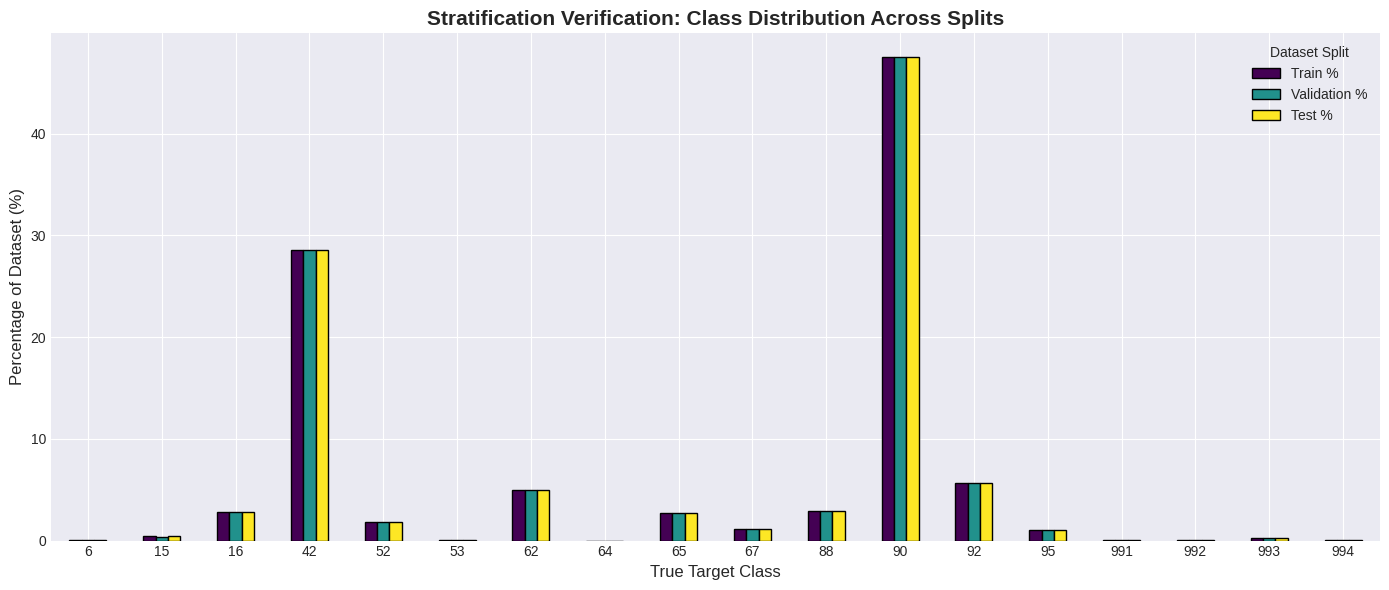

In [8]:
print("--- Verifying Class Stratification ---")

# Calculate the percentage of each class in the three splits
def get_class_percentages(df, name):
    pct = df['true_target'].value_counts(normalize=True).sort_index() * 100
    pct.name = name
    return pct

train_pct = get_class_percentages(train_meta, 'Train %')
val_pct = get_class_percentages(val_meta, 'Validation %')
test_pct = get_class_percentages(test_meta, 'Test %')

# Combine into a single dataframe for easy viewing
verification_df = pd.concat([train_pct, val_pct, test_pct], axis=1)
display(verification_df.round(3))

# Visual Proof
verification_df.plot(kind='bar', figsize=(14, 6), colormap='viridis', edgecolor='black')
plt.title('Stratification Verification: Class Distribution Across Splits', fontsize=15, fontweight='bold')
plt.xlabel('True Target Class', fontsize=12)
plt.ylabel('Percentage of Dataset (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Dataset Split')
plt.tight_layout()
plt.show()

### Phase 5: Exporting the "Source of Truth"

To keep our GitHub repository clean and lightweight, we will not export the massive dataframes containing all the metadata features. 

Instead, we extract only the `object_id` column from each subset. We will save these as `train_ids.csv`, `val_ids.csv`, and `test_ids.csv`. These three lightweight files serve as the absolute "Source of Truth" for the entire project. When it is time to build the PyTorch DataLoaders for the individual architectures, the models will reference these specific ID lists to pull their data.

In [9]:
print("--- Exporting ID Ledgers ---")

# Isolate just the ID columns
train_ids = train_meta[['object_id']]
val_ids = val_meta[['object_id']]
test_ids = test_meta[['object_id']]

# Save to CSV in the Kaggle working directory
train_ids.to_csv('train_ids.csv', index=False)
val_ids.to_csv('val_ids.csv', index=False)
test_ids.to_csv('test_ids.csv', index=False)

print("SUCCESS: Data successfully stratified and IDs exported.")
print("- train_ids.csv")
print("- val_ids.csv")
print("- test_ids.csv")
print("\nThe Shared Data Splitting Pipeline is complete.")

--- Exporting ID Ledgers ---
SUCCESS: Data successfully stratified and IDs exported.
- train_ids.csv
- val_ids.csv
- test_ids.csv

The Shared Data Splitting Pipeline is complete.
